# PS1 — benchmark-quality normalization experiment

Snapshot: **2026-09-13**  
Plans: **ChatGPT Plus, Claude Pro, Google AI Pro, SuperGrok**

This notebook implements the **empirical benchmark-quality component** $B_{p,j}$ used in the PS1 proposal.

Current PS1 scope:
- compute workload-specific benchmark-quality scores for **Reasoning, Coding, and Agentic** use;
- compare them with a single normalized Artificial Analysis composite-score baseline;
- run one-at-a-time sensitivity tests on the **raw benchmark inputs**;
- report benchmark score per dollar as a descriptive diagnostic.

The full research framework is

$\mathrm{SUU}_{p,j}=C_{p,j}B_{p,j}$,

but provider-specific usage capacity $C_{p,j}$ has **not yet been empirically measured**. Therefore, this notebook does **not** report final subscription-level SUU or SUU-per-dollar values.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. FROZEN INPUT SNAPSHOT
# ============================================================
# Source used in the proposal: Artificial Analysis Intelligence Index v4.3
# NOTE: No provider usage-capacity C values are inserted in this PS1 notebook.

DATA = [{'provider': 'ChatGPT Plus', 'model': 'GPT-6 Astra (max)', 'price': 20.0, 'aa_index': 53, 'aa_briefcase': 1562, 'gdpval_aa': 1580, 'automationbench': 68, 'terminal_bench': 59, 'scicode': 56, 'hle': 55, 'gdp_pdf': 31, 'critpt': 32, 'omniscience': 43, 'lcr': 81}, {'provider': 'Claude Pro', 'model': 'Claude Fable 5.1 (max with fallback)', 'price': 20.0, 'aa_index': 53, 'aa_briefcase': 1662, 'gdpval_aa': 1764, 'automationbench': 59, 'terminal_bench': 52, 'scicode': 63, 'hle': 59, 'gdp_pdf': 26, 'critpt': 30, 'omniscience': 43, 'lcr': 85}, {'provider': 'Google AI Pro', 'model': 'Gemini 3.8 Flash (high)', 'price': 19.99, 'aa_index': 41, 'aa_briefcase': 1202, 'gdpval_aa': 1464, 'automationbench': 60, 'terminal_bench': 20, 'scicode': 57, 'hle': 48, 'gdp_pdf': 21, 'critpt': 18, 'omniscience': 30, 'lcr': 81}, {'provider': 'SuperGrok', 'model': 'Grok 4.6 (high)', 'price': 30.0, 'aa_index': 44, 'aa_briefcase': 1534, 'gdpval_aa': 1643, 'automationbench': 67, 'terminal_bench': 21, 'scicode': 56, 'hle': 43, 'gdp_pdf': 17, 'critpt': 17, 'omniscience': 30, 'lcr': 80}]

df = pd.DataFrame(DATA)
df

,provider,model,price,aa_index,aa_briefcase,gdpval_aa,automationbench,terminal_bench,scicode,hle,gdp_pdf,critpt,omniscience,lcr
0,ChatGPT Plus,GPT-6 Astra (max),20.00,53,1562,1580,68,59,56,55,31,32,43,81
1,Claude Pro,Claude Fable 5.1 (max with fallback),20.00,53,1662,1764,59,52,63,59,26,30,43,85
2,Google AI Pro,Gemini 3.8 Flash (high),19.99,41,1202,1464,60,20,57,48,21,18,30,81
3,SuperGrok,Grok 4.6 (high),30.00,44,1534,1643,67,21,56,43,17,17,30,80


## 2. Workload-specific benchmark-quality scores

Each raw benchmark is normalized by the best score among the four compared plans.

- **Reasoning:** HLE, GDP.pdf, CritPt, Omniscience, LCR
- **Coding:** Terminal-Bench, SciCode
- **Agentic:** AA-Briefcase, GDPval-AA, AutomationBench

For workload $j$,

$
B_{p,j}
=
\frac{1}{|K_j|}
\sum_{k\in K_j}
\frac{S_{p,k}}{\max_q S_{q,k}}.
$

The user-facing **Overall benchmark-quality score** is the equal-weight mean of the three workload scores.

In [2]:
GROUPS = {
    "reasoning": ["hle", "gdp_pdf", "critpt", "omniscience", "lcr"],
    "coding": ["terminal_bench", "scicode"],
    "agentic": ["aa_briefcase", "gdpval_aa", "automationbench"],
}

BENCHMARK_COLS = [
    "hle", "gdp_pdf", "critpt", "omniscience", "lcr",
    "terminal_bench", "scicode",
    "aa_briefcase", "gdpval_aa", "automationbench",
]

# Sensitivity perturbations create decimal values, so use float explicitly.
df[BENCHMARK_COLS] = df[BENCHMARK_COLS].astype(float)

for workload, cols in GROUPS.items():
    normalized = df[cols].div(df[cols].max(axis=0), axis=1)
    df[f"B_{workload}"] = normalized.mean(axis=1)

# Baseline reference: Artificial Analysis composite score normalized to the best plan.
df["B_composite_reference"] = df["aa_index"] / df["aa_index"].max()

scores = pd.DataFrame({
    "provider": df["provider"],
    "Reasoning": 100 * df["B_reasoning"],
    "Coding": 100 * df["B_coding"],
    "Agentic": 100 * df["B_agentic"],
})

scores["Overall"] = scores[["Reasoning", "Coding", "Agentic"]].mean(axis=1)
scores["price"] = df["price"]
scores["Overall benchmark score / $"] = scores["Overall"] / scores["price"]

scores.round(3)

,provider,Reasoning,Coding,Agentic,Overall,price,Overall benchmark score / $
0,ChatGPT Plus,97.703,94.444,94.517,95.555,20.00,4.778
1,Claude Pro,95.524,94.068,95.588,95.060,20.00,4.753
2,Google AI Pro,74.082,62.187,81.184,72.484,19.99,3.626
3,SuperGrok,68.946,62.241,94.656,75.281,30.00,2.509


## 3. Baseline vs. workload-specific modification

**Baseline:** one normalized Artificial Analysis composite score.

$
B^{\mathrm{base}}_p
=
\frac{S^{\mathrm{AA}}_p}{\max_q S^{\mathrm{AA}}_q}.
$

**Modification:** replace the single aggregate score with separate Reasoning, Coding, and Agentic benchmark-quality components, then report their equal-weight Overall score.

This comparison tests whether one composite score hides meaningful workload-specific differences.

In [3]:
baseline_comparison = pd.DataFrame({
    "provider": df["provider"],
    "baseline_composite": 100 * df["B_composite_reference"],
    "modified_overall": scores["Overall"],
})

baseline_comparison["delta_points"] = (
    baseline_comparison["modified_overall"]
    - baseline_comparison["baseline_composite"]
)

baseline_comparison.round(3)

,provider,baseline_composite,modified_overall,delta_points
0,ChatGPT Plus,100.000,95.555,-4.445
1,Claude Pro,100.000,95.060,-4.940
2,Google AI Pro,77.358,72.484,-4.874
3,SuperGrok,83.019,75.281,-7.738


## 4. One-at-a-time sensitivity analysis

Each **raw benchmark input** is perturbed one at a time by $\pm10\%$ and $\pm20\%$.  
After each perturbation, all workload and Overall benchmark-quality scores are recomputed.

Because normalization uses the best score among the compared plans, perturbing one plan can also change another plan's normalized score. The code therefore records effects on **all four target plans**, not only on the perturbed plan.

In [4]:
PERTURBATIONS = [-0.20, -0.10, 0.10, 0.20]

def workload_scores(x):
    y = x.copy()

    for workload, cols in GROUPS.items():
        normalized = y[cols].div(y[cols].max(axis=0), axis=1)
        y[f"Score_{workload}"] = 100 * normalized.mean(axis=1)

    y["Score_overall"] = y[
        ["Score_reasoning", "Score_coding", "Score_agentic"]
    ].mean(axis=1)

    return y

base_scores = workload_scores(df)
rows = []

for source_provider in df["provider"]:
    for parameter in BENCHMARK_COLS:

        original = df.loc[
            df["provider"] == source_provider,
            parameter
        ].iloc[0]

        for delta in PERTURBATIONS:
            trial = df.copy()

            trial.loc[
                trial["provider"] == source_provider,
                parameter
            ] = original * (1 + delta)

            trial_scores = workload_scores(trial)

            for target_provider in df["provider"]:
                base = base_scores.loc[
                    base_scores["provider"] == target_provider,
                    "Score_overall"
                ].iloc[0]

                new = trial_scores.loc[
                    trial_scores["provider"] == target_provider,
                    "Score_overall"
                ].iloc[0]

                rows.append({
                    "source_provider": source_provider,
                    "parameter": parameter,
                    "perturbation_pct": 100 * delta,
                    "target_provider": target_provider,
                    "baseline_overall": base,
                    "new_overall": new,
                    "delta_overall_pct": 100 * (new / base - 1),
                })

sensitivity = pd.DataFrame(rows)

# Largest absolute effect observed anywhere in the OAT experiment.
global_max = (
    sensitivity
    .assign(abs_change=lambda x: x["delta_overall_pct"].abs())
    .sort_values("abs_change", ascending=False)
    .head(1)
)

global_max[[
    "source_provider",
    "parameter",
    "perturbation_pct",
    "target_provider",
    "baseline_overall",
    "new_overall",
    "delta_overall_pct"
]].round(3)

,source_provider,parameter,perturbation_pct,target_provider,baseline_overall,new_overall,delta_overall_pct
418,Google AI Pro,scicode,-20.0,Google AI Pro,72.484,69.468,-4.161


## 5. Most influential inputs

The table below reports, for each perturbed provider/benchmark input, the largest absolute change produced in any compared provider's Overall benchmark-quality score.

In [5]:
importance = (
    sensitivity
    .assign(abs_change=lambda x: x["delta_overall_pct"].abs())
    .groupby(["source_provider", "parameter"], as_index=False)["abs_change"]
    .max()
    .sort_values(["source_provider", "abs_change"], ascending=[True, False])
)

importance.round(3)

,source_provider,parameter,abs_change
8,ChatGPT Plus,scicode,3.101
9,ChatGPT Plus,terminal_bench,2.575
1,ChatGPT Plus,automationbench,2.424
0,ChatGPT Plus,aa_briefcase,2.186
4,ChatGPT Plus,gdpval_aa,2.083
7,ChatGPT Plus,omniscience,1.395
6,ChatGPT Plus,lcr,1.330
5,ChatGPT Plus,hle,1.301
3,ChatGPT Plus,gdp_pdf,1.198
2,ChatGPT Plus,critpt,1.096


## 6. Paper-ready numerical checks

These values are the ones that should be copied into the proposal if the frozen input snapshot remains unchanged.

In [6]:
paper_values = baseline_comparison.copy()

paper_values["baseline_composite"] = paper_values["baseline_composite"].round(2)
paper_values["modified_overall"] = paper_values["modified_overall"].round(2)
paper_values["delta_points"] = paper_values["delta_points"].round(2)

print("Baseline vs. workload-specific modification:")
display(paper_values)

row = global_max.iloc[0]
print(
    "\nLargest ±20% OAT effect: "
    f"{row['source_provider']} / {row['parameter']} "
    f"{row['perturbation_pct']:+.0f}% -> "
    f"{row['target_provider']} Overall "
    f"{row['baseline_overall']:.2f} -> {row['new_overall']:.2f} "
    f"({row['delta_overall_pct']:.2f}%)"
)

Baseline vs. workload-specific modification:


,provider,baseline_composite,modified_overall,delta_points
0,ChatGPT Plus,100.00,95.55,-4.45
1,Claude Pro,100.00,95.06,-4.94
2,Google AI Pro,77.36,72.48,-4.87
3,SuperGrok,83.02,75.28,-7.74



Largest ±20% OAT effect: Google AI Pro / scicode -20% -> Google AI Pro Overall 72.48 -> 69.47 (-4.16%)


## 7. Example sensitivity visualization

This plot shows the effect of **+20% perturbations to ChatGPT Plus raw benchmark inputs on ChatGPT Plus's own Overall benchmark-quality score**.

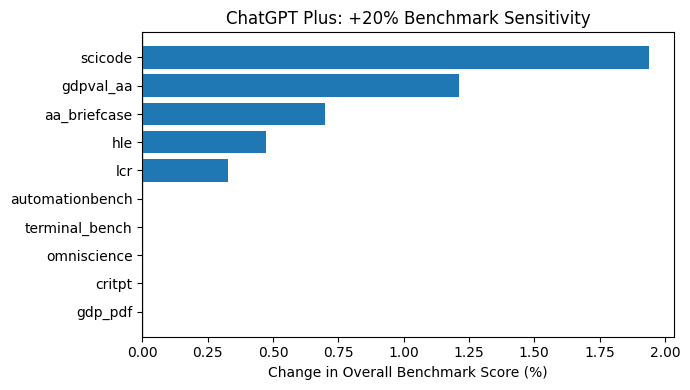

In [7]:
PROVIDER_TO_PLOT = "ChatGPT Plus"

plot_df = sensitivity[
    (sensitivity["source_provider"] == PROVIDER_TO_PLOT) &
    (sensitivity["target_provider"] == PROVIDER_TO_PLOT) &
    (sensitivity["perturbation_pct"] == 20)
].sort_values("delta_overall_pct")

plt.figure(figsize=(7, 4))
plt.barh(
    plot_df["parameter"],
    plot_df["delta_overall_pct"]
)
plt.axvline(0, linewidth=1)
plt.xlabel("Change in Overall Benchmark Score (%)")
plt.title(f"{PROVIDER_TO_PLOT}: +20% Benchmark Sensitivity")
plt.tight_layout()
plt.show()

## 8. Future extension: empirical usage capacity

The next-stage experiment will measure provider-specific usage capacity $C_{p,j}$ using fixed reference workloads and quota depletion.

Only after those measurements are available should the notebook compute

$
\mathrm{SUU}_{p,j}=C_{p,j}B_{p,j},
\qquad
\mathrm{SUU/\$}_{p,j}
=
\frac{\mathrm{SUU}_{p,j}}{P_p}.
$

No synthetic capacity values are used in the current PS1 numerical results.